In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [27]:
from google.colab import files
files.upload()

Saving test.csv to test (4).csv
Saving train.csv to train (4).csv


{'test (4).csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,S

In [28]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

Survival rate of people traveling alone: 30.353817504655495
Survival rate of people NOT alone: 50.56497175141242


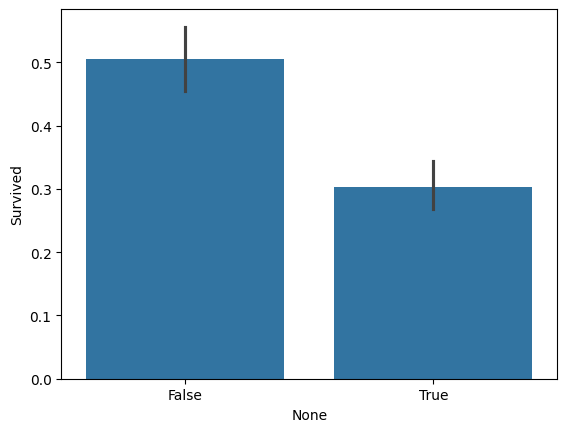

In [29]:
# Plot using condition directly
sns.barplot(
    x=(train["SibSp"] == 0) & (train["Parch"] == 0),
    y=train["Survived"]
)

# Percentage calculations
print("Survival rate of people traveling alone:",
      train[(train["SibSp"] == 0) & (train["Parch"] == 0)]["Survived"].mean() * 100)

print("Survival rate of people NOT alone:",
      train[(train["SibSp"] != 0) | (train["Parch"] != 0)]["Survived"].mean() * 100)

Percentage of females who survived: 74.20382165605095
Percentage of males who survived: 18.890814558058924


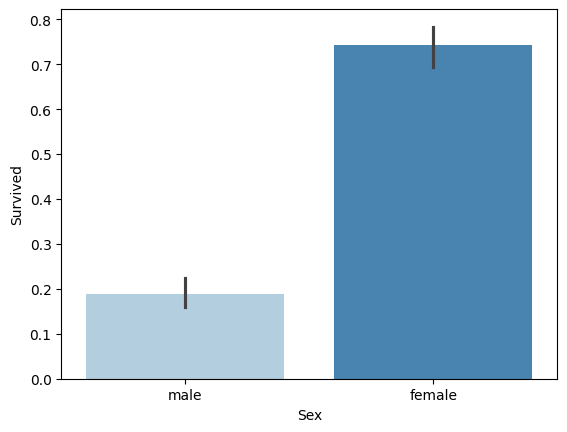

In [30]:
sns.barplot(x="Sex", y="Survived", data=train, palette = "Blues")

#print percentages of females vs. males that survive
print("Percentage of females who survived:", train["Survived"][train["Sex"] == 'female'].value_counts(normalize = True)[1]*100)

print("Percentage of males who survived:", train["Survived"][train["Sex"] == 'male'].value_counts(normalize = True)[1]*100)

Survival rate in Pclass 1: 62.96296296296296
Survival rate in Pclass 2: 47.28260869565217
Survival rate in Pclass 3: 24.236252545824847


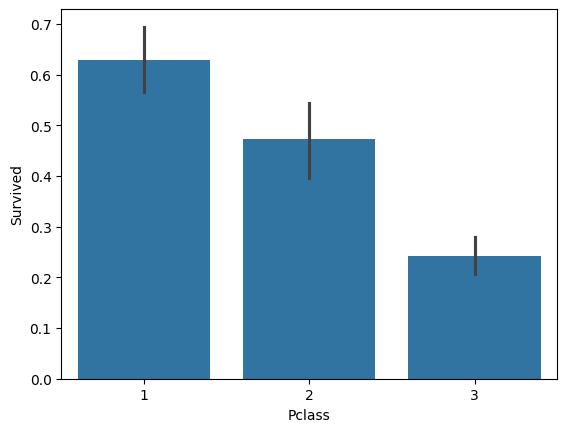

In [31]:
sns.barplot(x="Pclass", y="Survived", data=train)

print("Survival rate in Pclass 1:",
      train[train["Pclass"] == 1]["Survived"].mean() * 100)

print("Survival rate in Pclass 2:",
      train[train["Pclass"] == 2]["Survived"].mean() * 100)

print("Survival rate in Pclass 3:",
      train[train["Pclass"] == 3]["Survived"].mean() * 100)

Passengers in higher class (Pclass 1) have a higher survival rate compared to lower classes. This supports the hypothesis that socioeconomic status affected survival.

Survival rate (SibSp=0): 34.53947368421053
Survival rate (SibSp>0): 46.64310954063604


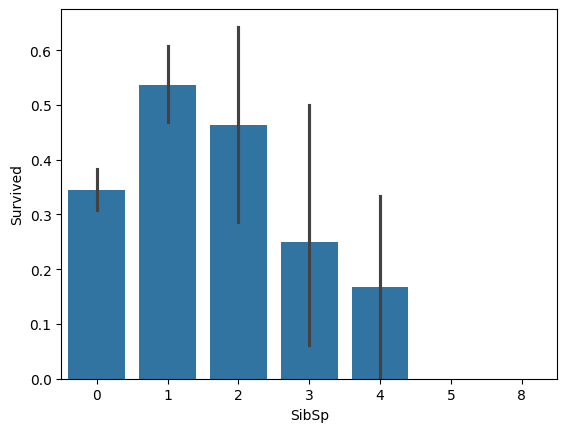

In [32]:
sns.barplot(x="SibSp", y="Survived", data=train)

print("Survival rate (SibSp=0):",
      train[train["SibSp"] == 0]["Survived"].mean() * 100)

print("Survival rate (SibSp>0):",
      train[train["SibSp"] > 0]["Survived"].mean() * 100)

Passengers with no siblings/spouse (SibSp = 0) show a different survival pattern compared to those traveling with family. This indicates family size may influence survival chances.

Survival rate (Parch=0): 34.365781710914455
Survival rate (Parch>0): 51.173708920187785


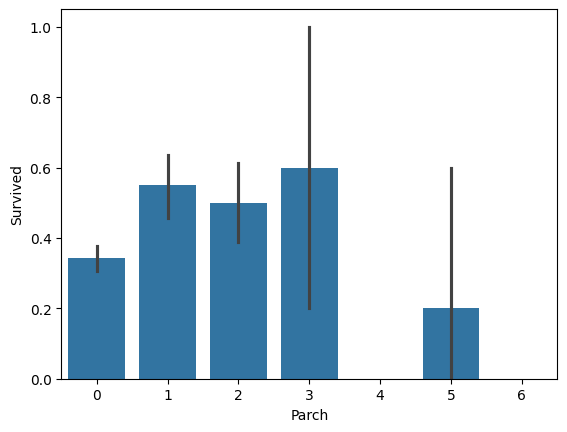

In [33]:
sns.barplot(x="Parch", y="Survived", data=train)

print("Survival rate (Parch=0):",
      train[train["Parch"] == 0]["Survived"].mean() * 100)

print("Survival rate (Parch>0):",
      train[train["Parch"] > 0]["Survived"].mean() * 100)

Passengers traveling without parents/children (Parch = 0) show different survival rates compared to those with family. This suggests family relationships may impact survival.

Survival rate of children: 50.35971223021583
Survival rate of adults: 36.17021276595745


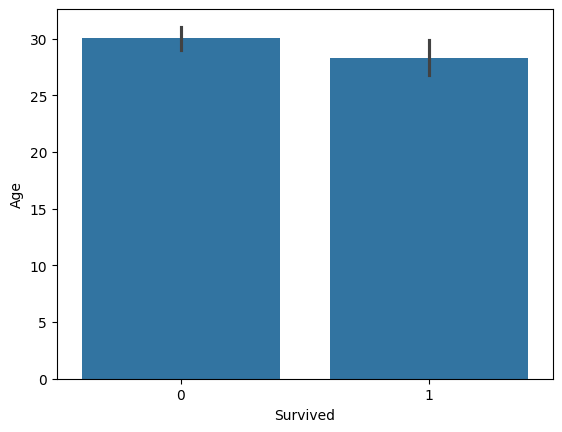

In [61]:
# Plot survival vs age (binned automatically)
sns.barplot(x="Survived", y="Age", data=train)

# Percentage of children (Age <= 18)
print("Survival rate of children:",
      train[train["Age"] <= 18]["Survived"].mean() * 100)

# Percentage of adults (Age > 18)
print("Survival rate of adults:",
      train[train["Age"] > 18]["Survived"].mean() * 100)

Passengers aged 18 or below are considered children. The survival rate of children is higher than adults, supporting the hypothesis that younger passengers had better chances of survival.

In [35]:
test.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Cabin Feature

In [36]:
train = train.drop(['Cabin'], axis=1, errors='ignore')
test = test.drop(['Cabin'], axis=1, errors='ignore')

Embarked Feature

In [37]:
# Find most frequent value
print(train['Embarked'].value_counts())

# Fill missing values with most frequent (mode)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Age Feature (Fill missing values)

In [38]:
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

In [39]:
combine = [train, test]

In [40]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
pd.crosstab(train['Title'], train['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [41]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace(['Countess', 'Lady', 'Sir'], 'Royal')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.285714
5,Royal,1.000000


In [42]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Royal": 5, "Rare": 6}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [45]:
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

In [46]:
train = train.drop(['Name'], axis=1)
test = test.drop(['Name'], axis=1)

In [47]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

In [48]:
train['Embarked'] = train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [49]:
# Fill missing value
test['Fare'].fillna(test['Fare'].median(), inplace=True)

# Convert into groups
train['FareBand'] = pd.qcut(train['Fare'], 4, labels=[1,2,3,4])
test['FareBand'] = pd.qcut(test['Fare'], 4, labels=[1,2,3,4])

# Drop original Fare
train = train.drop(['Fare'], axis=1)
test = test.drop(['Fare'], axis=1)

In [50]:
train.head()
test.head()
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Embarked,0
Title,0


In [52]:
# Import models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score



In [54]:
train = train.drop(['Ticket'], axis=1)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data
X = train.drop(['Survived', 'PassengerId'], axis=1)
y = train['Survived']

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

In [59]:
# 1. Support Vector Machine
svm = SVC()
svm.fit(x_train, y_train)
svm_pred = svm.predict(x_val)
print("SVM Accuracy:", accuracy_score(y_val, svm_pred) * 100)

# 2. Decision Tree
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_val)
print("Decision Tree Accuracy:", accuracy_score(y_val, dt_pred) * 100)

# 3. Random Forest
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_val)
print("Random Forest Accuracy:", accuracy_score(y_val, rf_pred) * 100)

# 4. KNN
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
knn_pred = knn.predict(x_val)
print("KNN Accuracy:", accuracy_score(y_val, knn_pred) * 100)

SVM Accuracy: 67.0391061452514
Decision Tree Accuracy: 79.3296089385475
Random Forest Accuracy: 80.44692737430168
KNN Accuracy: 75.97765363128491
